# Corporate Bond Returns Summary

In [1]:
import sys
sys.path.insert(0, "./src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import chartbook

BASE_DIR = chartbook.env.get_project_root()
DATA_DIR = BASE_DIR / "_data"

## Data Overview

This pipeline produces corporate bond returns data from OpenBondAssetPricing.com, including:
- Individual bond returns
- Portfolio returns grouped by credit spread deciles

### Data Source

The data comes from [openbondassetpricing.com](https://openbondassetpricing.com/), which provides
TRACE (Trade Reporting and Compliance Engine) data with market microstructure noise (MMN) adjustments.

### Data Cleaning (Following Nozawa 2017)

The data cleaning procedure follows the methodology established by Nozawa (2017):

1. **Bond Selection**: Exclude bonds with floating rate coupons and non-callable option features
2. **Price Filters**: Remove observations where bond price exceeds matched Treasury price
3. **Return Reversals**: Eliminate observations with adjacent return products < -0.04
4. **Synthetic Treasury Construction**: For each corporate bond, a synthetic Treasury with identical cash flows is constructed

### Portfolio Construction

Bonds are sorted into 10 deciles based on credit spread (CS), and value-weighted returns are computed:

$$r_{portfolio, t} = \sum_{i \\in portfolio} w_{i,t} \\cdot ret_{i,t}$$

where weights are based on bond market value (MMN-adjusted clean price × amount outstanding).

## Individual Bond Returns

In [2]:
df_bonds = pd.read_parquet(DATA_DIR / "ftsfr_corp_bond_returns.parquet")
print(f"Shape: {df_bonds.shape}")
print(f"Columns: {df_bonds.columns.tolist()}")
print(f"\nDate range: {df_bonds['ds'].min()} to {df_bonds['ds'].max()}")
print(f"Number of unique bonds: {df_bonds['unique_id'].nunique()}")

Shape: (1859498, 3)
Columns: ['unique_id', 'ds', 'y']

Date range: 2002-08-31 00:00:00 to 2025-03-31 00:00:00
Number of unique bonds: 53389


In [3]:
df_bonds.describe()

,ds,y
count,1859498,1.859498e+06
mean,2015-11-16 05:37:56.120113408,4.687305e-03
min,2002-08-31 00:00:00,-9.981083e-01
25%,2010-10-31 00:00:00,-6.126034e-03
50%,2016-11-30 00:00:00,3.716778e-03
75%,2021-06-30 00:00:00,1.522560e-02
max,2025-03-31 00:00:00,9.000757e+00
std,NaN,4.981669e-02


## Portfolio Returns by Credit Spread Decile

In [4]:
df_portfolio = pd.read_parquet(DATA_DIR / "ftsfr_corp_bond_portfolio_returns.parquet")
print(f"Shape: {df_portfolio.shape}")
print(f"Columns: {df_portfolio.columns.tolist()}")
print(f"\nDate range: {df_portfolio['ds'].min()} to {df_portfolio['ds'].max()}")
print(f"Credit spread deciles: {sorted(df_portfolio['unique_id'].unique())}")

Shape: (2690, 3)
Columns: ['unique_id', 'ds', 'y']

Date range: 2002-08-31 00:00:00 to 2024-12-31 00:00:00
Credit spread deciles: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]


In [5]:
# Summary statistics by decile
portfolio_stats = df_portfolio.groupby("unique_id")["y"].agg(
    ["count", "mean", "std", "min", "max"]
)
portfolio_stats.columns = ["Count", "Mean", "Std", "Min", "Max"]
portfolio_stats

,Count,Mean,Std,Min,Max
unique_id,,,,,
1.0,269,0.003514,0.010835,-0.039874,0.088565
2.0,269,0.004218,0.014543,-0.039339,0.119262
3.0,269,0.004707,0.016579,-0.044883,0.108928
4.0,269,0.004874,0.019123,-0.059339,0.106005
5.0,269,0.004991,0.020533,-0.069163,0.085645
6.0,269,0.005662,0.021498,-0.075524,0.081520
7.0,269,0.005901,0.021977,-0.074917,0.078264
8.0,269,0.006415,0.023988,-0.103130,0.104339
9.0,269,0.007719,0.036159,-0.183776,0.314782


## Time Series of Portfolio Returns

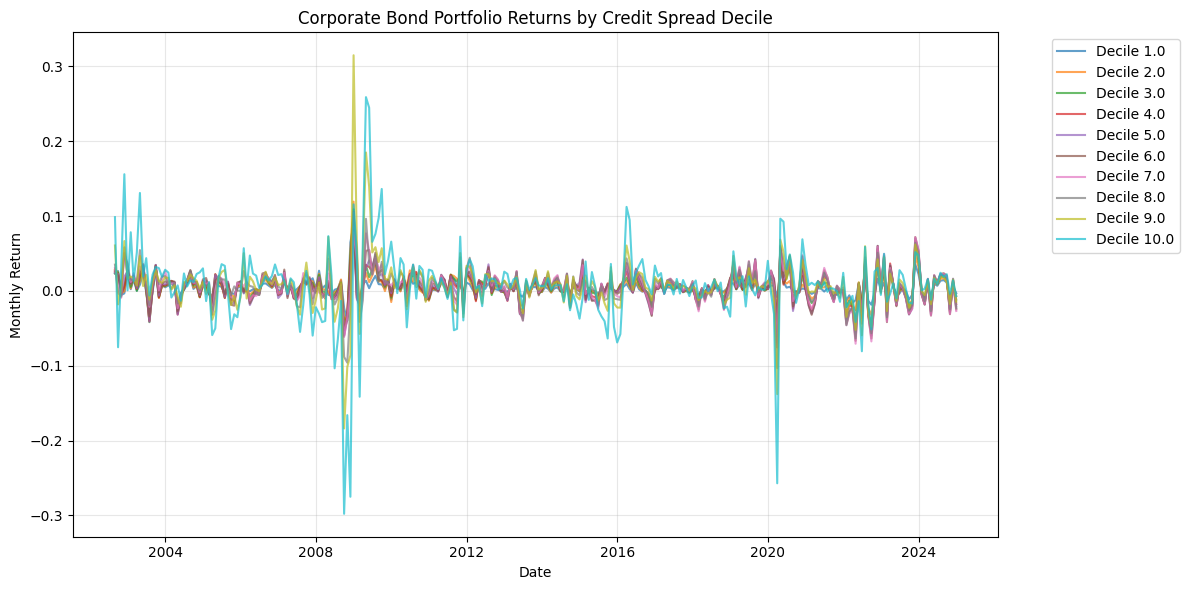

In [6]:
# Pivot for plotting
df_pivot = df_portfolio.pivot(index="ds", columns="unique_id", values="y")
df_pivot = df_pivot[sorted(df_pivot.columns, key=lambda x: int(x))]

fig, ax = plt.subplots(figsize=(12, 6))
for col in df_pivot.columns:
    ax.plot(df_pivot.index, df_pivot[col], label=f"Decile {col}", alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Return")
ax.set_title("Corporate Bond Portfolio Returns by Credit Spread Decile")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Correlation Matrix

Correlation between credit spread deciles shows how returns move together across the credit risk spectrum.

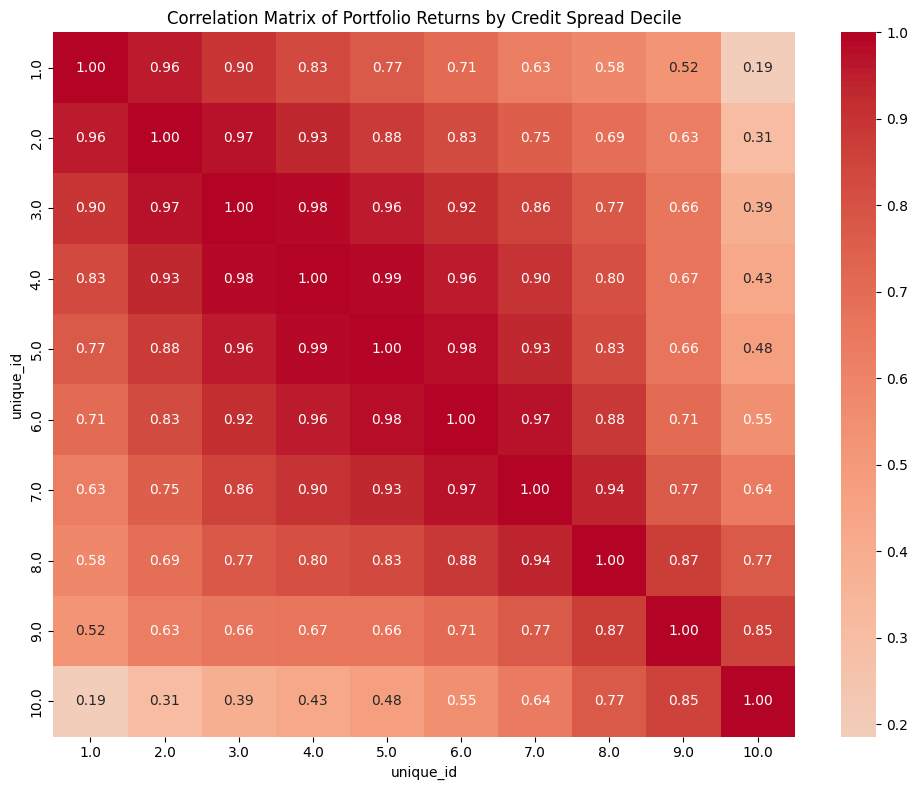

In [7]:
corr_matrix = df_pivot.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix of Portfolio Returns by Credit Spread Decile")
plt.tight_layout()
plt.show()

## Return Distribution by Decile

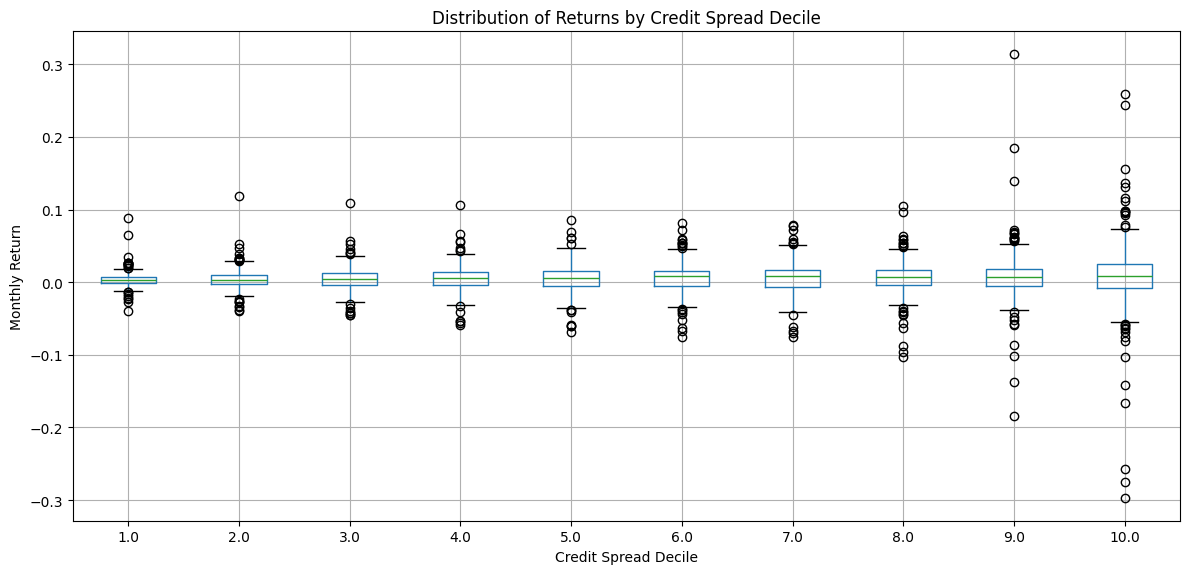

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
df_portfolio.boxplot(column="y", by="unique_id", ax=ax)
ax.set_xlabel("Credit Spread Decile")
ax.set_ylabel("Monthly Return")
ax.set_title("Distribution of Returns by Credit Spread Decile")
plt.suptitle("")  # Remove automatic title
plt.tight_layout()
plt.show()

## Credit Spread Decile Definitions

| Decile | Description |
|--------|-------------|
| 1 | Lowest credit spread (safest bonds) |
| 2-9 | Intermediate credit spreads |
| 10 | Highest credit spread (riskiest bonds) |

Bonds are sorted into deciles based on their credit spread relative to matched Treasury securities.
Higher deciles represent bonds with wider credit spreads, typically indicating higher credit risk.